In [1]:
import scanpy as sc
import velot

In [2]:
from datasets import load

adata, cfg = load("oligodendroglioma")

In [3]:
adata

AnnData object with n_obs × n_vars = 4044 × 23686
    obs: 'cell_type_group', 'cell_type_subgroup', 'dif_stem_x', 'dif_stem_y', 'fate_state', 'clusters_id'
    uns: 'neighbors'
    obsm: 'X_cell_cycle', 'X_dif_stem'
    obsp: 'distances', 'connectivities'

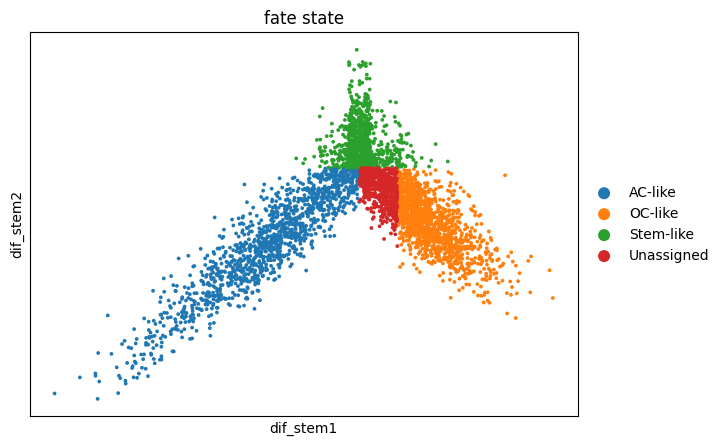

In [4]:
sc.pl.scatter(adata, basis="dif_stem", color="fate_state")

In [5]:
import scanpy as sc

# 1. Replace any existing raw NaNs with 0 (if your input table had missing entries)
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
if sp.issparse(adata.X):
    adata.X.data = np.nan_to_num(adata.X.data, nan=0.0)
else:
    adata.X = np.nan_to_num(adata.X, nan=0.0)

# 2. Filter out empty cells and dead genes FIRST (prevents 0/0 = NaN!)
sc.pp.filter_cells(adata, min_genes=10)   # or min_counts=1
sc.pp.filter_genes(adata, min_cells=3)    # removes zero-variance genes

# 3. Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 4. Highly Variable Genes (HVG)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

In [ ]:

# 5. PCA & Neighbors (Scanpy automatically uses HVGs if present)
sc.tl.pca(adata, n_comps=pca)
sc.pp.neighbors(adata, n_neighbors=20, use_rep="X_pca")

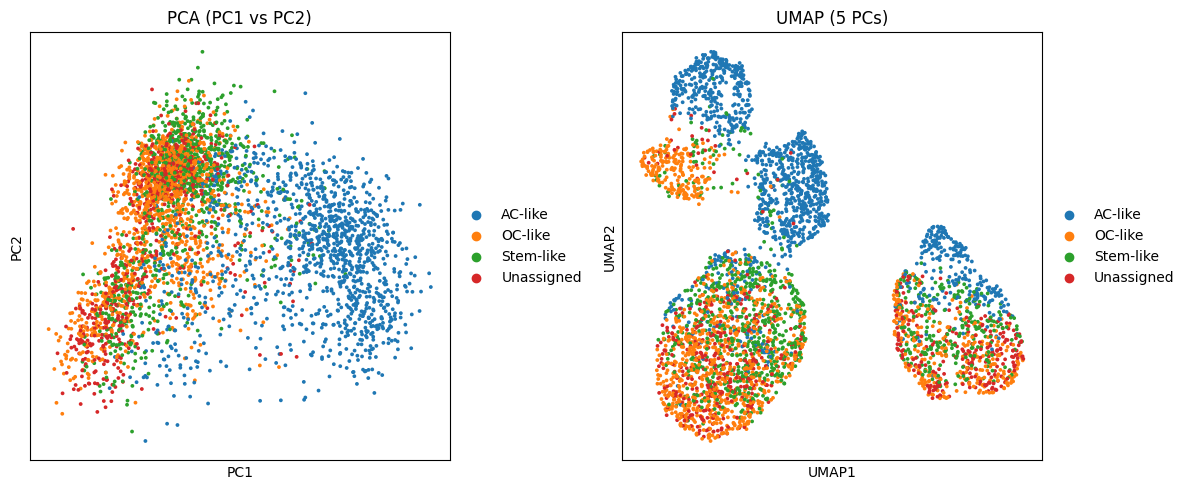

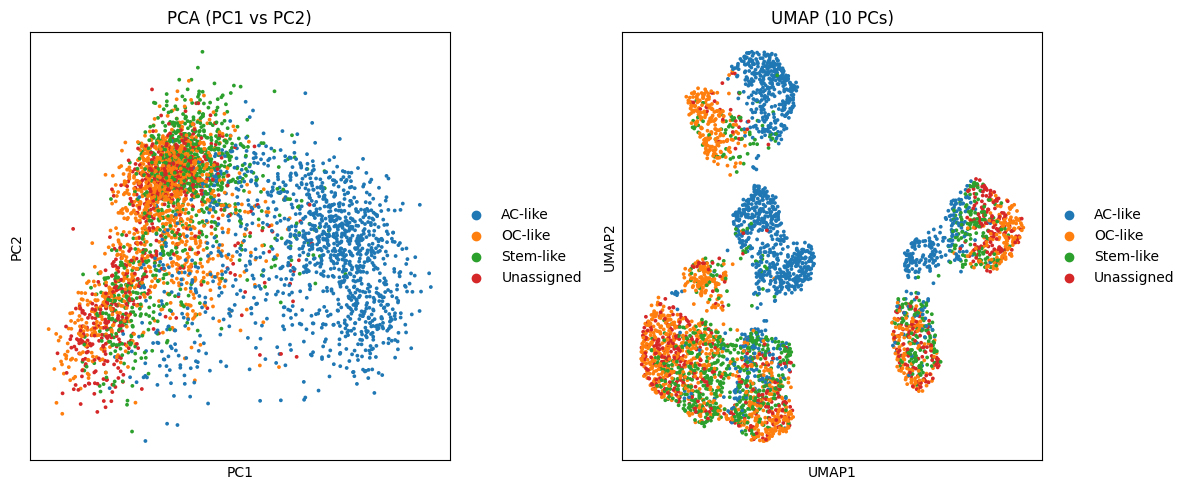

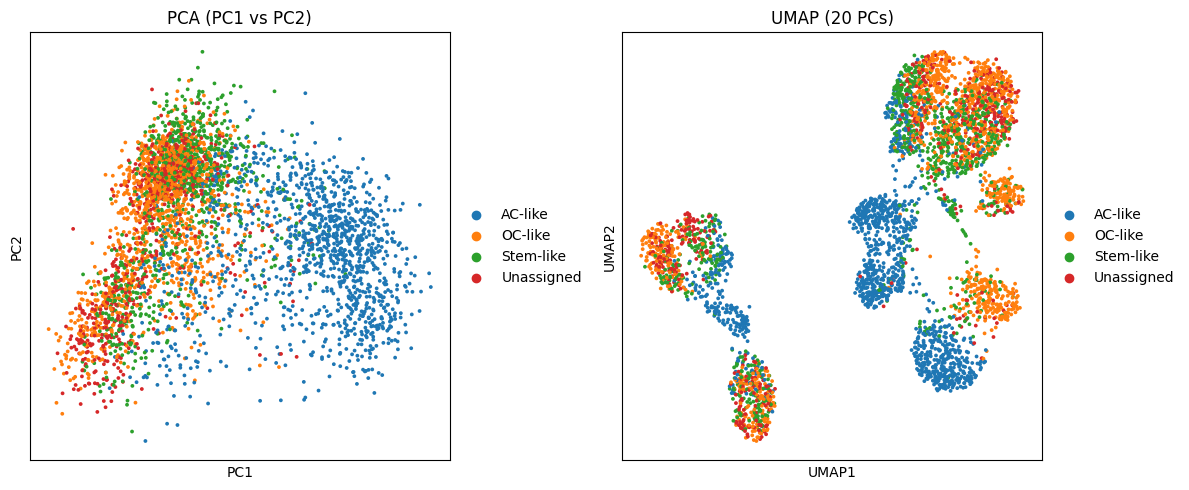

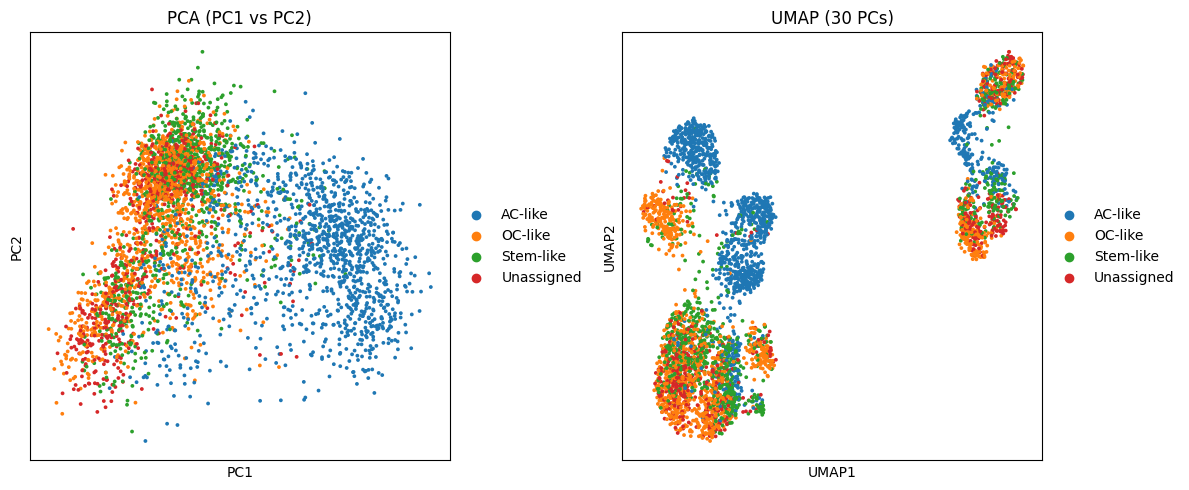

In [10]:
# Compute the max number of PCs once
sc.pp.pca(adata, n_comps=30)

for pca in [5, 10, 20, 30]:
    sc.pp.neighbors(adata, n_neighbors=20, n_pcs=pca, use_rep="X_pca")
    sc.tl.umap(adata)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sc.pl.pca(adata, color="fate_state", ax=axes[0], show=False, title=f"PCA (PC1 vs PC2)")
    sc.pl.umap(adata, color="fate_state", ax=axes[1], show=False, title=f"UMAP ({pca} PCs)")
    plt.tight_layout()
    plt.show()

In [ ]:
sc.pl.scatter(adata, )

In [7]:
METHODS = ["velot_unbalanced", "velot_gradient"]
SEED = "0"
FIELDS = ["raw", "smooth"]
DATASET = "gen_tree"
CLUSTERS_KEY = "clusters"
chr_code = ord("a")
letter = chr(chr_code)
show, save = True, False

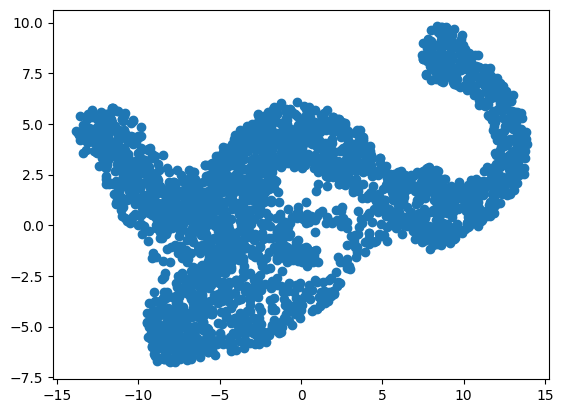

In [6]:
import matplotlib.pyplot as plt

plt.scatter(adata.obsm["X_umap"][:,0], adata.obsm["X_umap"][:,1])

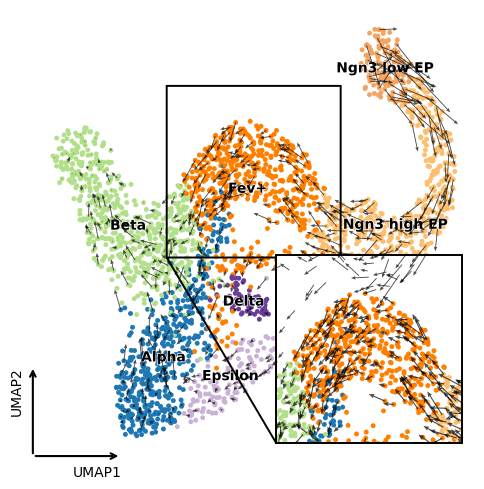

In [20]:
velot.pl.zoom_inset(
    velot.pl.velocity_quiver, adata,
    center=(0, 4), width=12.0, height=7.0,      # data coords of the basis
    loc="lower right", size=0.42,
    color=CLUSTERS_KEY, basis="umap",
    velocity_key=f"velot_velocity_raw_umap", title=None,
    subsample=500,
    inset_kwargs=dict(subsample=800, arrow_width=0.006),
    figsize=(5, 5), show=show, save=save,
    save_path=f"figure2_{letter}.png")

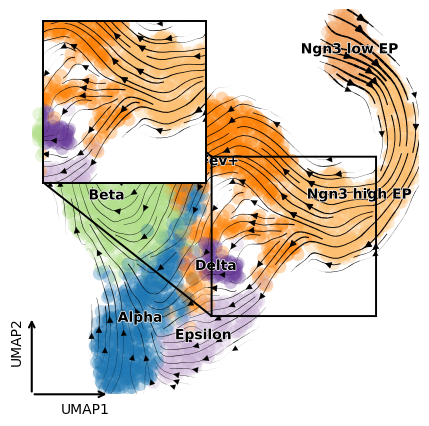

In [25]:
velot.pl.zoom_inset(
    velot.pl.velocity_stream, adata,
    center=(5, 0), width=12.0, height=7.0,      # data coords of the basis
    loc="upper left", size=0.42,
    color=CLUSTERS_KEY, basis="umap",
    velocity_key=f"velot_velocity_raw", title=None,
    figsize=(5, 5), show=show, save=save,
    save_path=f"figure2_{letter}.png"
)

In [ ]:
def fig_metrics(runs, cfg, dataset, out):
    _, mbasis, suffix = _keys(cfg)
    truth_key = cfg.get("truth_key")
    nrow = len(runs)
    # datasets with a known velocity field get a third panel
    has_truth = bool(truth_key) and all(
        truth_key in a.obsm for _, a, _ in runs)
    ncol = 3 if has_truth else 2
    fig, axes = plt.subplots(nrow, ncol, figsize=(7 * ncol, 5 * nrow),
                             squeeze=False)
    printed = []
    for i, (method, adata, _) in enumerate(runs):
        labels = adata.obs[cfg["clusters_key"]].astype(str).values
        scored = {}
        for field, key in (("raw", f"velot_velocity_raw_{suffix}"),
                           ("smooth", f"velot_velocity_{suffix}")):
            res = velot.metrics.summary(
                adata, cluster_edges=cfg["edges"],
                cluster_key=cfg["clusters_key"], embedding_key=mbasis,
                velocity_key=key, print_results=False)
            if has_truth:
                # recomputed here, exactly as run_velot.py computes it, so
                # the figure stays an independent check on the CSV
                res.update(_cosine_to_truth(
                    adata.obsm[key], adata.obsm[truth_key], labels))
            scored[field] = res
        velot.pl.metric_summary(scored, orientation="vertical",
                                ax=axes[i], legend=(i == 0))
        axes[i, 0].annotate(method, xy=(-0.20, 0.5), xycoords="axes fraction",
                            rotation=90, ha="center", va="center",
                            fontsize=16, fontweight="bold",
                            annotation_clip=False)
        printed.append((method, scored["raw"], scored["smooth"]))
    title = "ICCoh, CBDir and cosine to truth" if has_truth \
        else "ICCoh and CBDir"
    fig.suptitle(f"{dataset} — {title}, raw against smoothed",
                 fontsize=19, fontweight="bold", y=0.997)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    _save(fig, f"{out}/{dataset}_metrics.png")

    # echo the numbers so they can be diffed against runs.csv by eye
    cols = ["iccoh_mean", "cbdir_mean"] + (["cos_mean"] if has_truth else [])
    print("    recomputed from the h5ad (compare with runs_wide.csv):")
    header = "".join(f"{c.replace('_mean',''):>11s}{'':>11s}" for c in cols)
    print(f"      {'method':18s} " + "".join(
        f"{c.replace('_mean','')+'_raw':>12s}{c.replace('_mean','')+'_smo':>12s}"
        for c in cols))
    for m, raw, smo in printed:
        vals = "".join(f"{raw[c]:12.4f}{smo[c]:12.4f}" for c in cols)
        print(f"      {m:18s} " + vals)

In [9]:
import os
import json
from pathlib import Path

# Define directories
src_dir = Path("results2")
real_dir = Path("results2/real")
synth_dir = Path("results2/synthetic")

# Create destination directories if they don't exist
real_dir.mkdir(parents=True, exist_ok=True)
synth_dir.mkdir(parents=True, exist_ok=True)

# Define dataset categories
real_datasets = ["erythroid", "pancreas", "murine", "hindbrain"]

# Iterate through files in the source directory
for filename in os.listdir(src_dir):
    if not filename.endswith(".json"):
        continue
        
    # Condition 2: Only process files with seed 0
    if "seed0" not in filename:
        continue

    # Extract prefix, dataset, and determine if it's "smooth"
    is_smooth = False
    if "_seed0_raw_" in filename:
        prefix, rest = filename.split("_seed0_raw_")
    elif "_seed0_smooth_" in filename:
        prefix, rest = filename.split("_seed0_smooth_")
        is_smooth = True
    else:
        continue  # Skip if it doesn't match the expected pattern

    # The dataset name is whatever comes after the seed/raw/smooth identifier
    dataset = rest.replace(".json", "")

    # Apply renaming rules for the method
    if prefix == "velot":
        method = "OT"
    elif prefix == "velot_gradient":
        method = "knn"
    elif prefix == "velot_unbalanced":
        method = "OT"
    else:
        continue # Skip unrecognized prefixes

    # Append _MLP if the original file was "smooth"
    if is_smooth:
        method += "_MLP"

    # Condition 1: Determine the target folder based on dataset name
    if dataset in real_datasets:
        dest_dir = real_dir
    else:
        dest_dir = synth_dir

    # Construct final file paths
    new_filename = f"{method}_{dataset}.json"
    src_path = src_dir / filename
    dest_path = dest_dir / new_filename

    # Read the original JSON
    with open(src_path, "r") as f:
        data = json.load(f)
    
    # Update the 'model' key to the new method name
    if "model" in data:
        data["model"] = method

    # Write the modified JSON to the new destination
    with open(dest_path, "w") as f:
        json.dump(data, f, indent=4)  # indent=4 keeps the JSON human-readable

    print(f"Processed: {filename} -> {dest_dir.name}/{new_filename}")

Processed: velot_seed0_raw_erythroid.json -> real/OT_erythroid.json
Processed: velot_seed0_smooth_erythroid.json -> real/OT_MLP_erythroid.json
Processed: velot_gradient_seed0_raw_erythroid.json -> real/knn_erythroid.json
Processed: velot_gradient_seed0_smooth_erythroid.json -> real/knn_MLP_erythroid.json
Processed: velot_seed0_raw_pancreas.json -> real/OT_pancreas.json
Processed: velot_seed0_smooth_pancreas.json -> real/OT_MLP_pancreas.json
Processed: velot_gradient_seed0_raw_pancreas.json -> real/knn_pancreas.json
Processed: velot_gradient_seed0_smooth_pancreas.json -> real/knn_MLP_pancreas.json
Processed: velot_seed0_raw_murine.json -> real/OT_murine.json
Processed: velot_seed0_smooth_murine.json -> real/OT_MLP_murine.json
Processed: velot_gradient_seed0_raw_murine.json -> real/knn_murine.json
Processed: velot_gradient_seed0_smooth_murine.json -> real/knn_MLP_murine.json
Processed: velot_seed0_raw_hindbrain.json -> real/OT_hindbrain.json
Processed: velot_seed0_smooth_hindbrain.json -

In [ ]:
from velot.benchmark import benchmark_summary_table

benchmark_summary_table(
    "results2/real",
    detail="per_dataset",
    save_csv="results2/real/summary_per_dataset.csv",
)
benchmark_summary_table(
    "results2/synthetic",
    detail="per_dataset",
    save_csv="results2/synthetic/summary_per_dataset.csv",
)

  Saved summary table: results2/real/summary_per_dataset.csv
  Saved summary table: results2/synthetic/summary_per_dataset.csv


,model,dataset,metric,mean,median,std,n,pvalue,significance,time_total
0,OT,bifurcation,cbdir,0.701888,0.750000,0.298342,812,NaN,,165.899299
1,OT,bifurcation,iccoh,0.576435,0.672546,0.356659,4995,NaN,,165.899299
2,OT,linear,cbdir,0.629343,0.636364,0.281413,662,NaN,,6.656458
3,OT,linear,iccoh,0.540025,0.680279,0.368858,4996,NaN,,6.656458
4,OT,trifurcation,cbdir,0.671641,0.700000,0.320495,1101,NaN,,160.985236
5,OT,trifurcation,iccoh,0.590617,0.692697,0.340193,4975,NaN,,160.985236
6,OT_MLP,bifurcation,cbdir,0.734080,0.777778,0.277512,812,NaN,,165.899299
7,OT_MLP,bifurcation,iccoh,0.992171,0.994706,0.011202,4995,NaN,,165.899299
8,OT_MLP,linear,cbdir,0.668452,0.666667,0.257442,662,NaN,,6.656458
9,OT_MLP,linear,iccoh,0.968994,0.993256,0.071993,4996,NaN,,6.656458


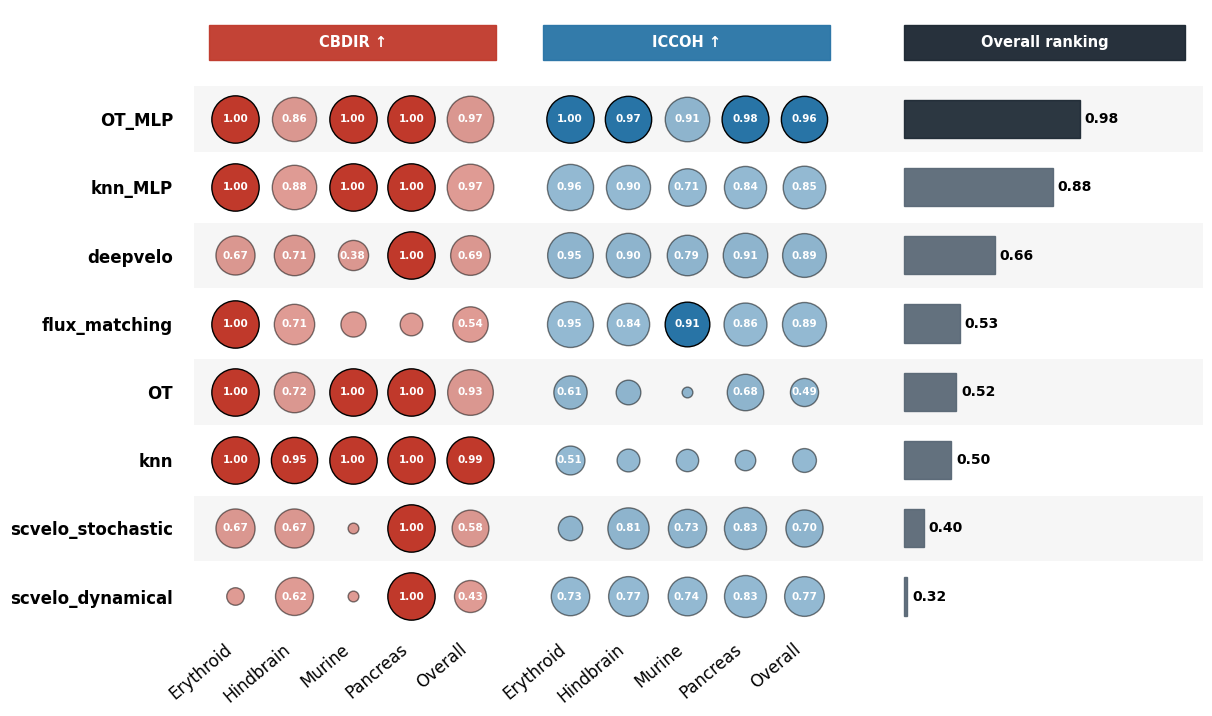

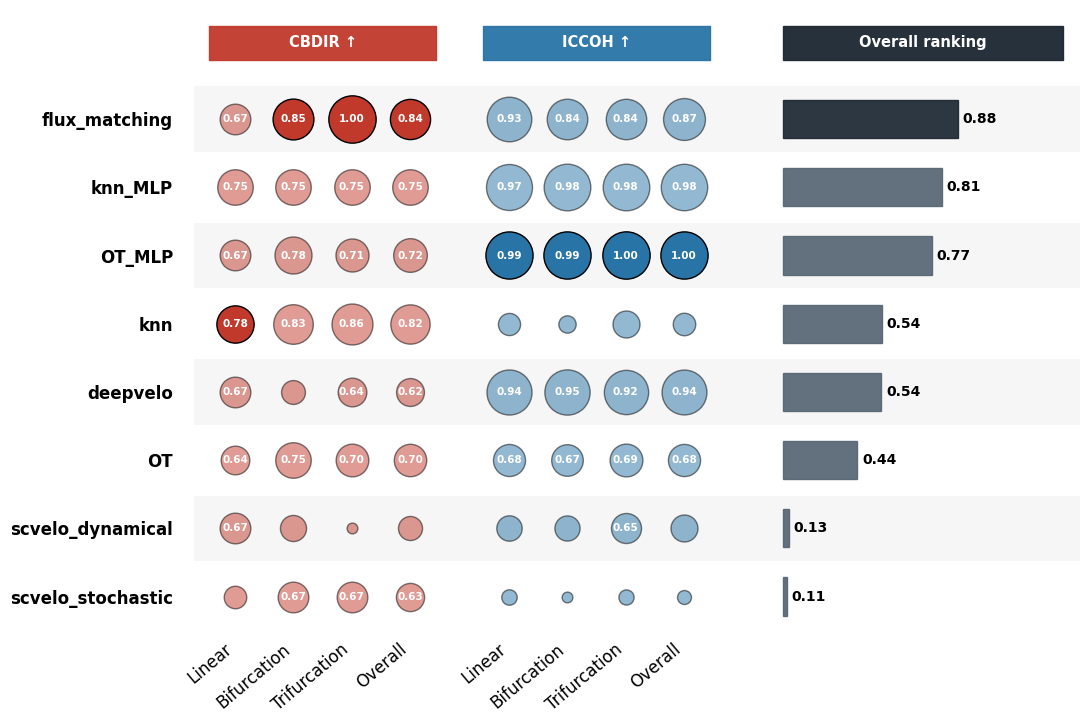

In [15]:
from velot.benchmark import benchmark_dotplot

benchmark_dotplot("results2/real", stat="median",
    # model_labels={
    #     "velot": "VelOT",
    #     "scvelo_dynamical": "scVelo (dynamical)",
    #     "scvelo_stochastic": "scVelo (stochastic)",
    #     "deepvelo": "DeepVelo",
    #     "flux_matching": "FluxMatching",
    # },
    legend=False, summary=False, include_timing=False
    # save="../figures/figure 5/figure5_a.png"
    );

benchmark_dotplot("results2/synthetic", stat="median",
    # model_labels={
    #     "velot": "VelOT",
    #     "scvelo_dynamical": "scVelo (dynamical)",
    #     "scvelo_stochastic": "scVelo (stochastic)",
    #     "deepvelo": "DeepVelo",
    #     "flux_matching": "FluxMatching",
    # },
    datasets_order=["linear", "bifurcation", "trifurcation"],
    legend=False, summary=False, include_timing=False
    # save="../figures/figure 5/figure5_b.png"
    );

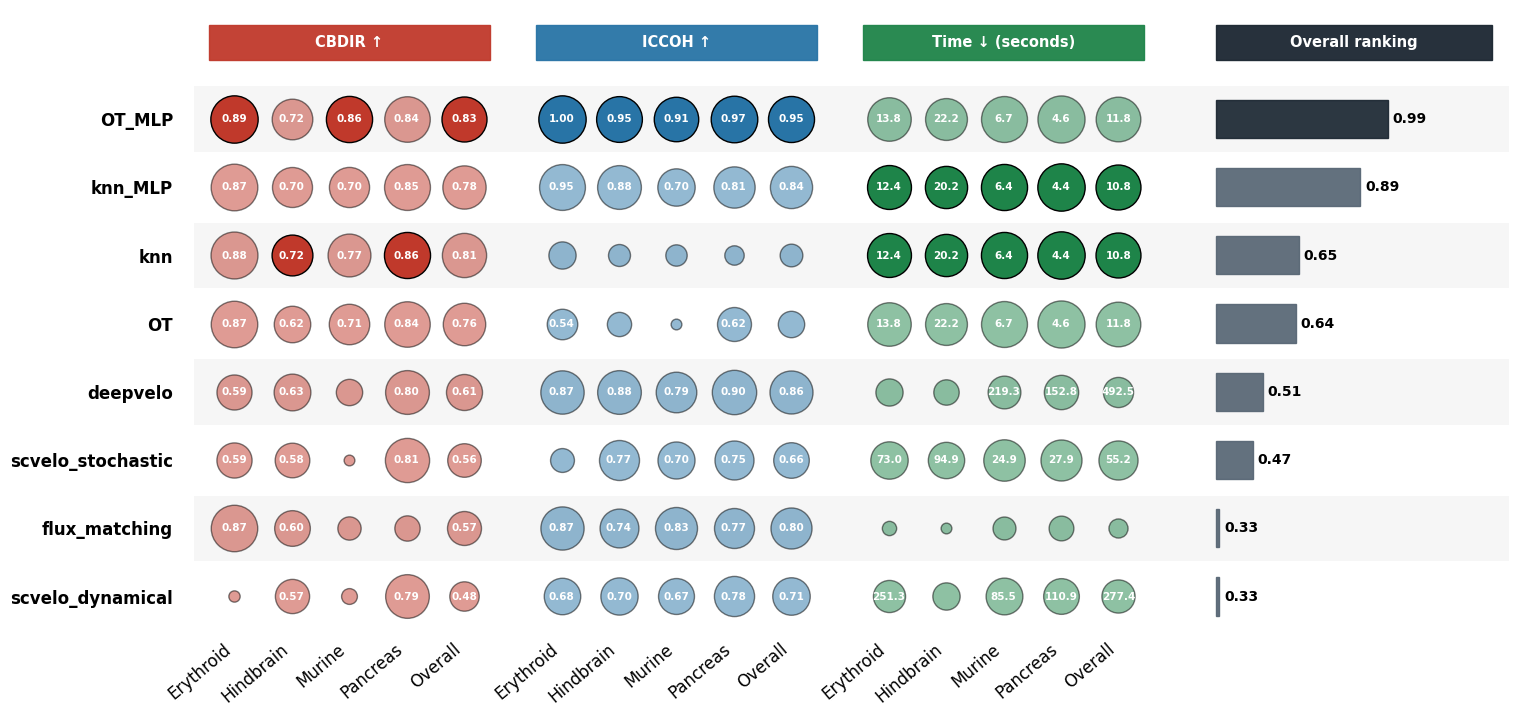

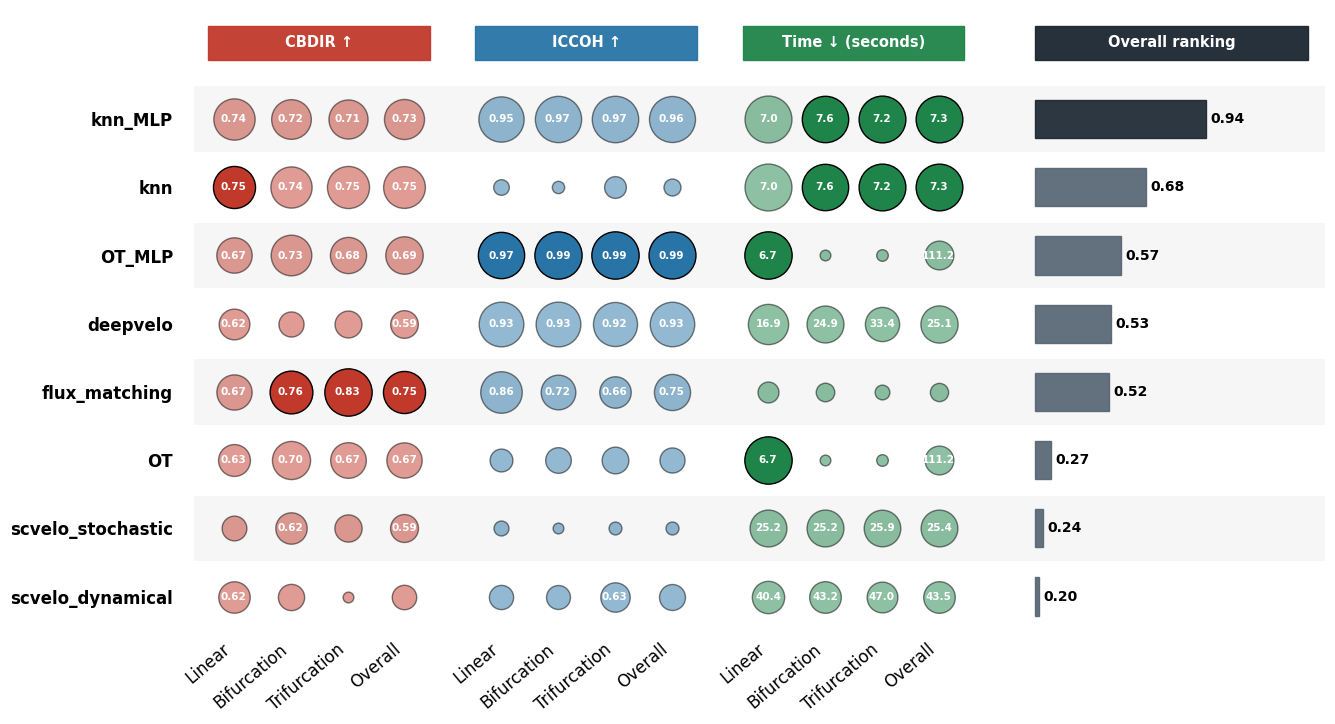

In [14]:
benchmark_dotplot("results2/real", stat="mean",
    # model_labels={
    #     "velot": "VelOT",
    #     "scvelo_dynamical": "scVelo (dynamical)",
    #     "scvelo_stochastic": "scVelo (stochastic)",
    #     "deepvelo": "DeepVelo",
    #     "flux_matching": "FluxMatching",
    # },
    legend=False, summary=False,
    # save="../figures/figure 5/figure5_a.png"
    );

benchmark_dotplot("results2/synthetic", stat="mean",
    # model_labels={
    #     "velot": "VelOT",
    #     "scvelo_dynamical": "scVelo (dynamical)",
    #     "scvelo_stochastic": "scVelo (stochastic)",
    #     "deepvelo": "DeepVelo",
    #     "flux_matching": "FluxMatching",
    # },
    datasets_order=["linear", "bifurcation", "trifurcation"],
    legend=False, summary=False,
    # save="../figures/figure 5/figure5_b.png"
    );

  Spatial clustering: 1 clusters via KMeans on X_pca (10D)
  Built 18 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 500, step: 500


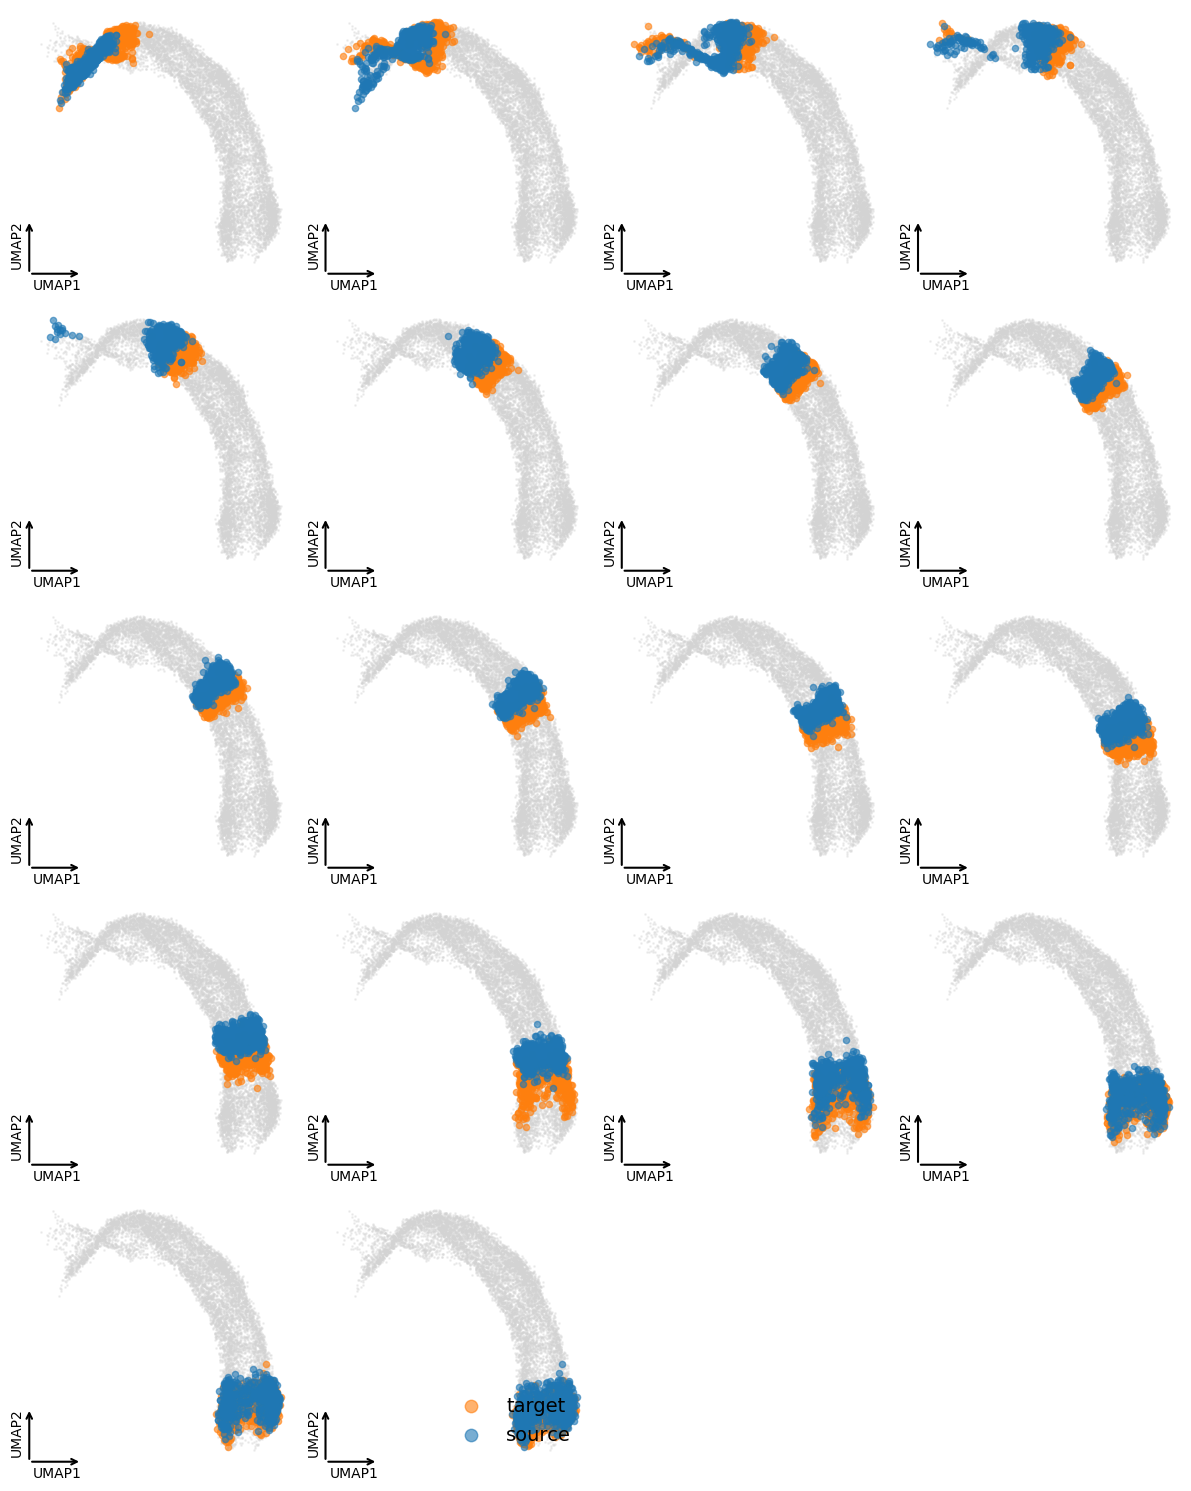

In [16]:
adata = sc.read_h5ad("/media/user/T7 Touch/PhD_Lucas/velot_peer_review/velot/article/data/Gastrulation/erythroid_velot.h5ad")
adata
WINDOWS_DICT = dict(
    basis= 'X_pca',
    n_clusters= 1,
    spatial_key= None,
    window_size= 500,
    min_window_size= 0,
    overlap_fraction= 0.0,
    tail_handling= 'drop',
    tail_threshold= 500
)
velot.tl.build_windows(adata, **WINDOWS_DICT)

velot.pl.windows(adata, max_show=20)

In [12]:
adata.obs["celltype"].value_counts()

celltype
Erythroid1             2929
Erythroid3             2697
Blood progenitors 2    2460
Erythroid2             1106
Blood progenitors 1     623
Name: count, dtype: int64

In [3]:
adata = sc.read_h5ad("/media/user/T7 Touch/PhD_Lucas/velot_peer_review/velot/article/datasets/pancreas_velot.h5ad")
adata

AnnData object with n_obs × n_vars = 2531 × 2000
    obs: 'day', 'proliferation', 'G2M_score', 'S_score', 'phase', 'clusters_coarse', 'clusters', 'clusters_fine', 'louvain_Alpha', 'louvain_Beta', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'dpt_pseudotime', 'pseudotime', 'clusters_id', 'velot_spatial_cluster', 'velot_confidence'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_colors', 'clusters_fine_colors', 'diffmap_evals', 'iroot', 'louvain_Alpha_colors', 'louvain_Beta_colors', 'neighbors', 'pca', 'recover_dynamics', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'velot_windows'
    obsm: 'X_diffmap', '

  Spatial clustering: 1 clusters via KMeans on X_pca (10D)
  Built 7 window pairs across 1 clusters (skipped 0 small clusters)
  Window size: 300, step: 300


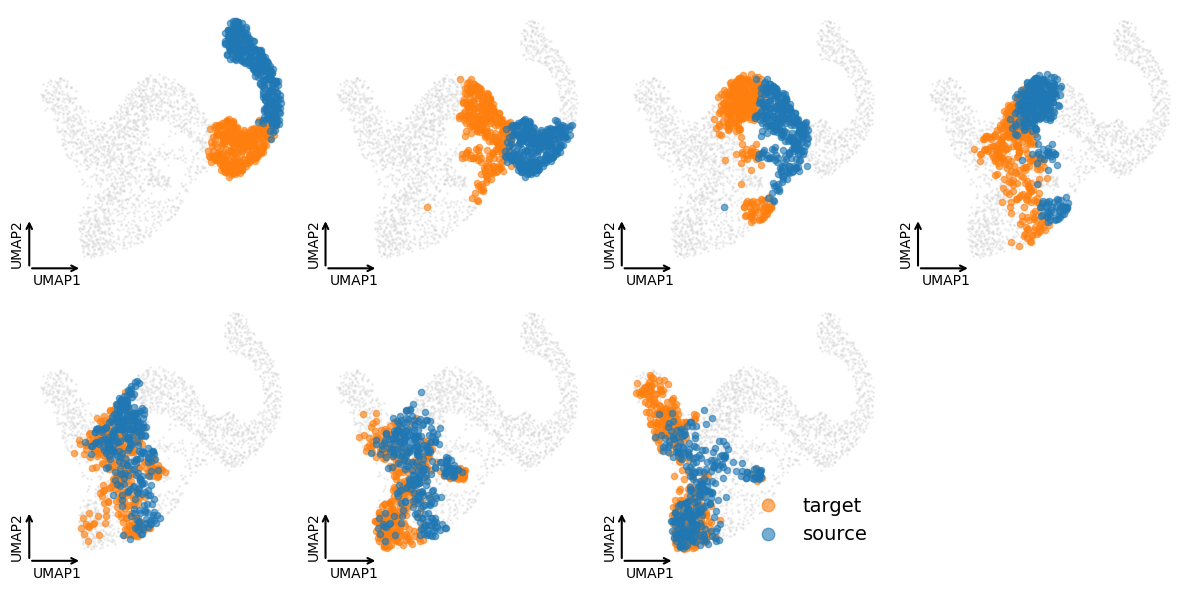

In [35]:
WINDOWS_DICT = dict(
    basis= 'X_pca',
    n_clusters= 1,
    spatial_key= None,
    window_size= 300,
    min_window_size= 0,
    overlap_fraction= 0.0,
    tail_handling= 'drop',
    tail_threshold= 300
)
velot.tl.build_windows(adata, **WINDOWS_DICT)

velot.pl.windows(adata)

In [20]:
adata.obs["clusters"].value_counts()

clusters
Beta            591
Fev+            587
Ngn3 high EP    529
Alpha           477
Epsilon         139
Ngn3 low EP     138
Delta            70
Name: count, dtype: int64

In [22]:
adata

AnnData object with n_obs × n_vars = 9815 × 14352
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'n_counts', 'dpt_pseudotime', 'pseudotime', 'clusters_id', 'velot_spatial_cluster', 'velot_confidence', 'velot_transported_mass'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm', 'n_cells'
    uns: 'celltype_colors', 'diffmap_evals', 'iroot', 'neighbors', 'velot_raw_velocity_params', 'velot_smoothing', 'velot_windows'
    obsm: 'X_diffmap', 'X_pca', 'X_umap', 'velot_velocity_pca', 'velot_velocity_raw_pca', 'velot_velocity_raw_umap', 'velot_velocity_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [ ]:
import os
PATH = "benchmark_results/real/data"
DATASET = "erythroid"
adatas = [file for file in os.listdir(PATH) if ("smooth" in file) & (DATASET in file)]
ORDER = [
    "original",
    "no_knn",
    "cost_nn",
    "argmax",
    "exact",
    "unbalanced",
    "geodesic",
    "knn_gradient"
]

In [12]:
ORDER = [
    "original",
    "no_knn",
    "cost_nn",
    "argmax",
    "exact",
    "unbalanced",
    "geodesic",
    "knn_gradient"
]

In [14]:
sorted_adatas = sorted(
    adatas, 
    key=lambda x: next(i for i, keyword in enumerate(ORDER) if keyword in x)
)

In [1]:
from velot.benchmark import benchmark_summary_table

benchmark_summary_table(
    "benchmark_results/real",
    detail="per_dataset",
    save_csv="benchmark_results/real/summary_per_dataset.csv",
)

  Saved summary table: benchmark_results/real/summary_per_dataset.csv


,model,dataset,metric,mean,median,std,n,pvalue,significance,time_total
0,velot_argmax_raw,erythroid,cbdir,0.873606,1.000000,0.203911,1706,NaN,,216.529610
1,velot_argmax_raw,erythroid,iccoh,0.542514,0.609471,0.224934,9807,NaN,,216.529610
2,velot_argmax_raw,pancreas,cbdir,0.836689,1.000000,0.287204,460,NaN,,48.255925
3,velot_argmax_raw,pancreas,iccoh,0.619715,0.678391,0.301710,2529,NaN,,48.255925
4,velot_argmax_smooth,erythroid,cbdir,0.896150,1.000000,0.166195,1706,NaN,,216.529610
...,...,...,...,...,...,...,...,...,...,...
59,velot_unbalanced_raw,pancreas,iccoh,0.658277,0.730441,0.295898,2529,NaN,,95.093753
60,velot_unbalanced_smooth,erythroid,cbdir,0.896666,1.000000,0.167196,1706,NaN,,368.997780
61,velot_unbalanced_smooth,erythroid,iccoh,0.995447,0.996762,0.005112,9807,NaN,,368.997780
62,velot_unbalanced_smooth,pancreas,cbdir,0.843113,1.000000,0.289198,460,NaN,,95.093753


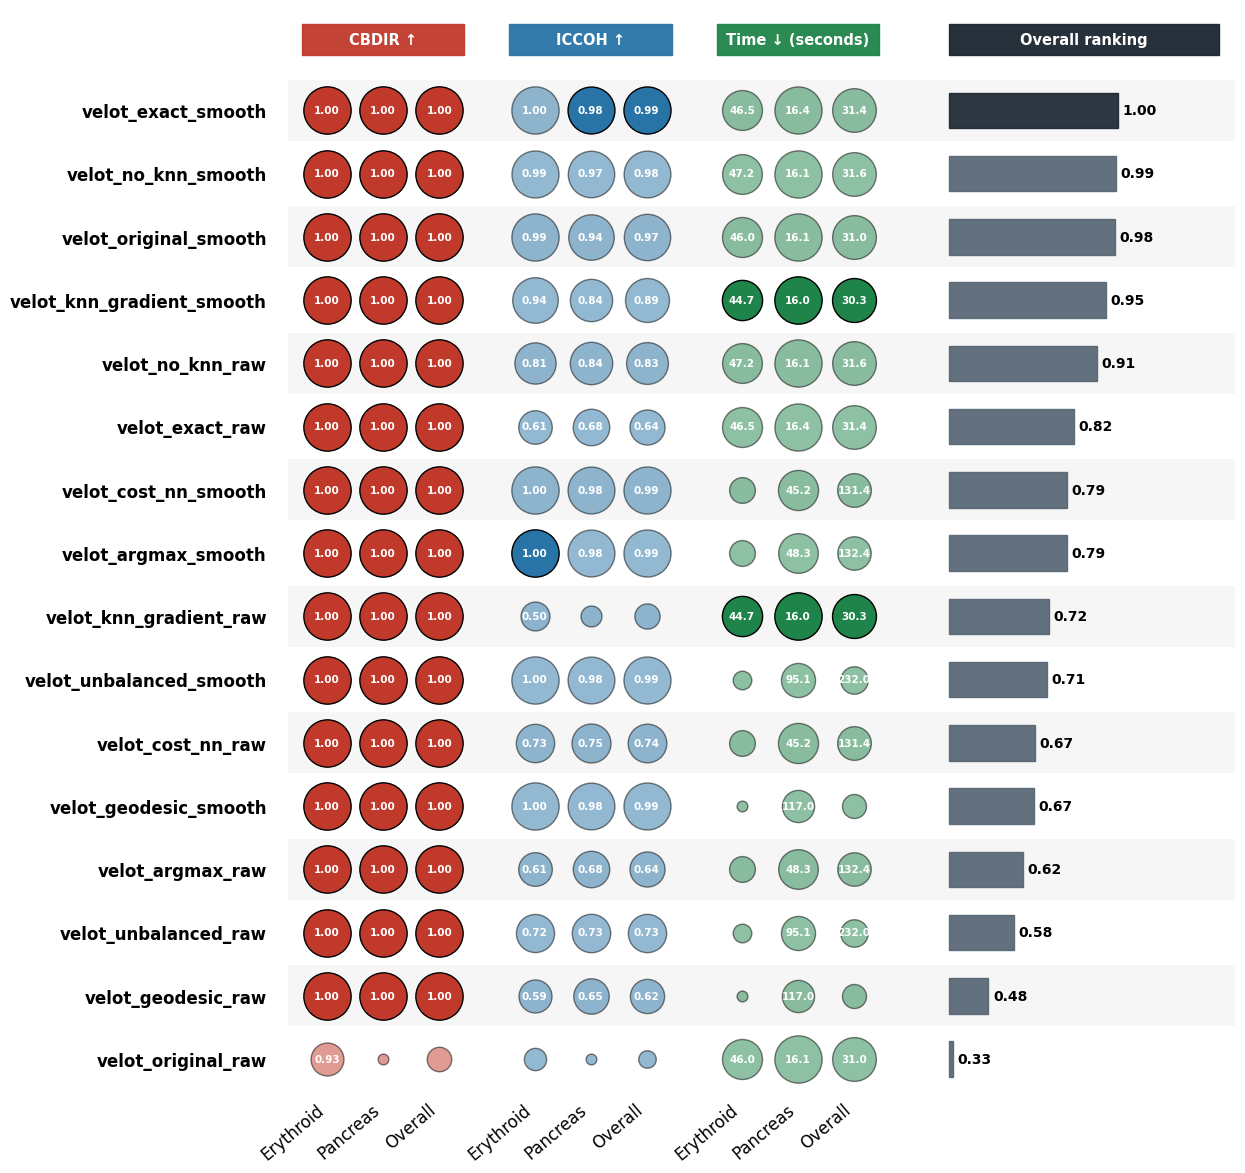

In [2]:
from velot.benchmark import benchmark_dotplot

benchmark_dotplot("benchmark_results/real", stat="median",
    legend=False, summary=False,
    );

In [2]:
from velot.benchmark import benchmark_comparison_individual

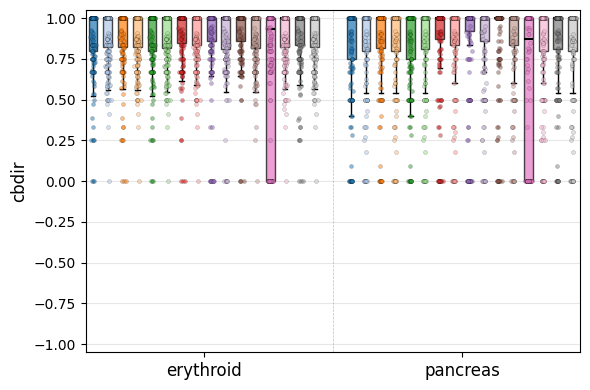

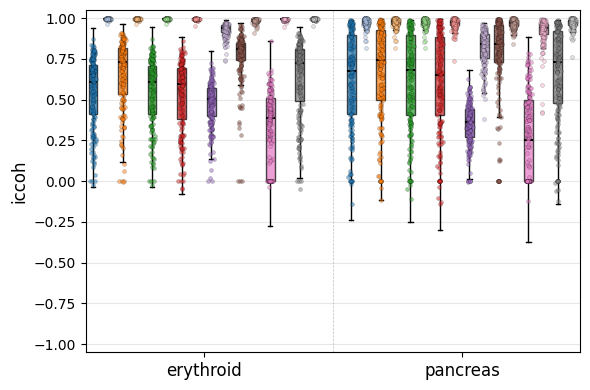

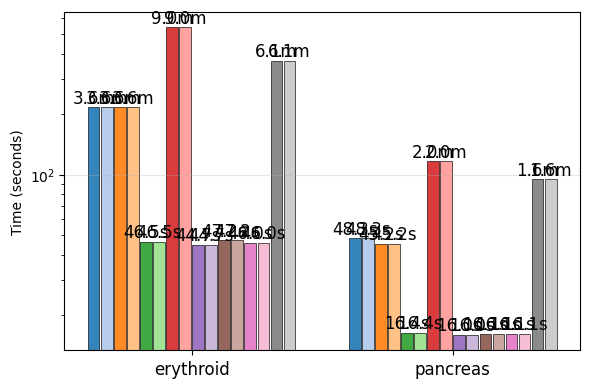

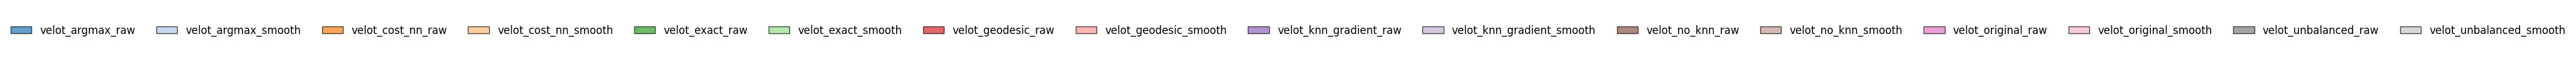

In [3]:
benchmark_comparison_individual(
    "benchmark_results/real",
    detail="per_dataset",
    save=False, show_significance=False
);

  Saved summary table: benchmark_results/real/summary_per_dataset.csv


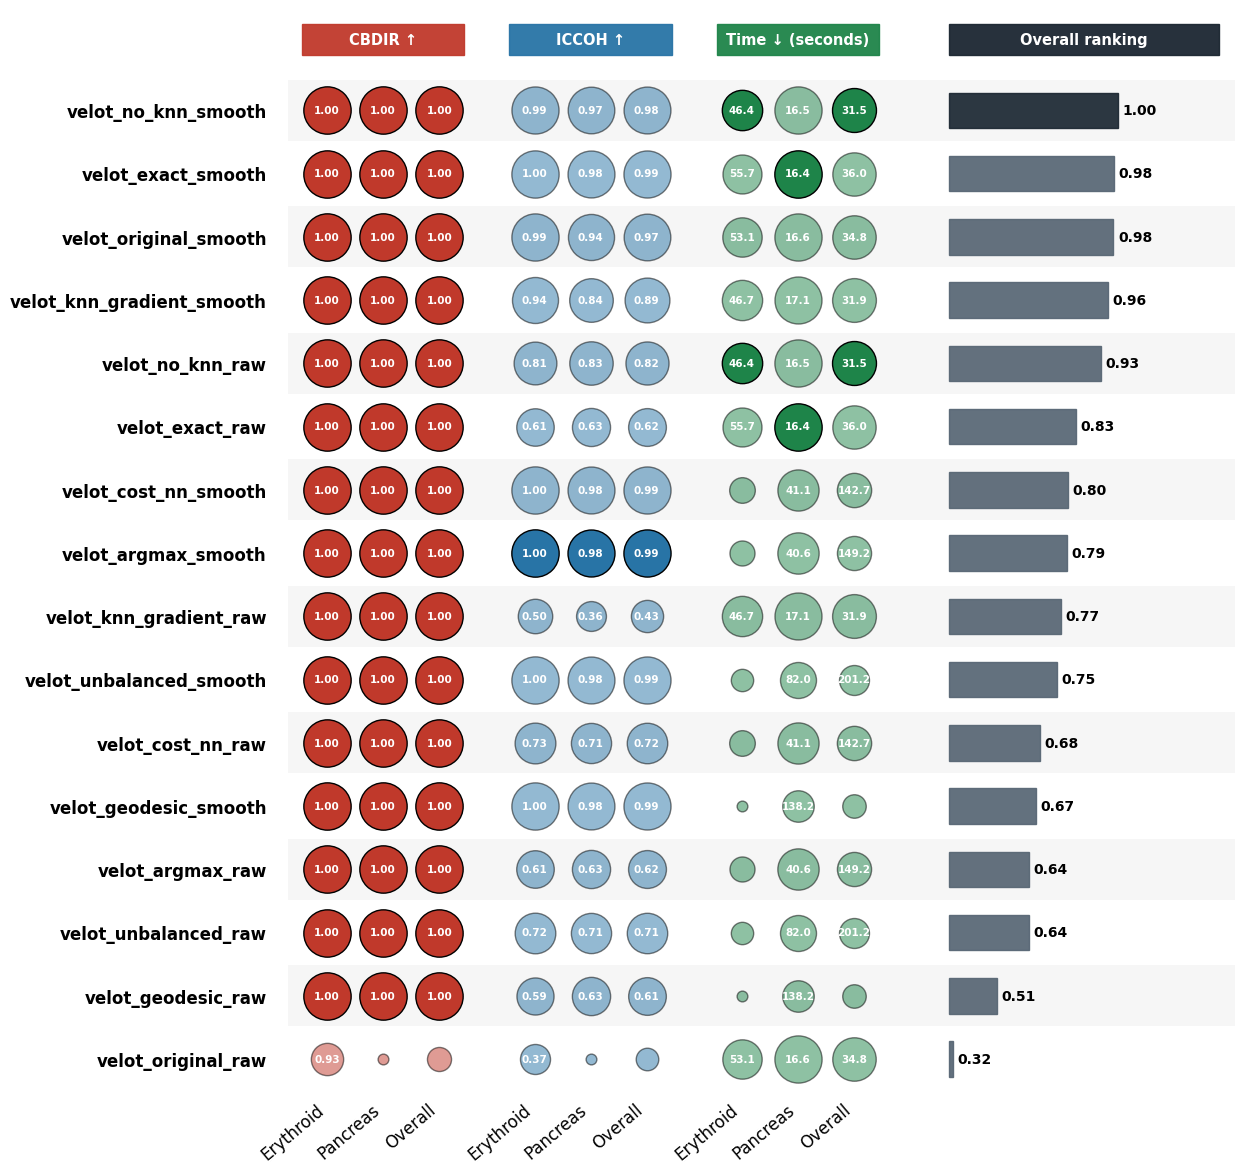

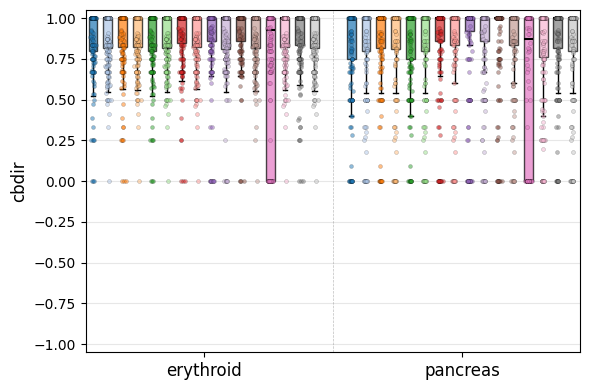

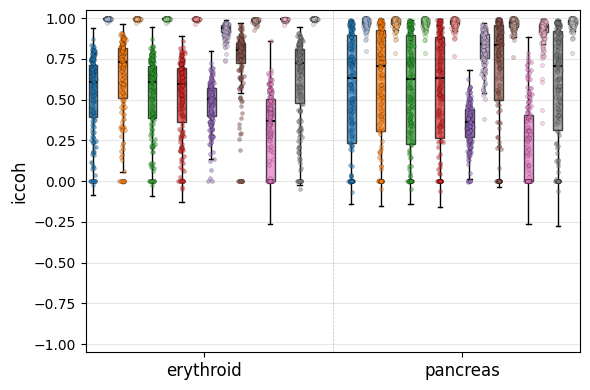

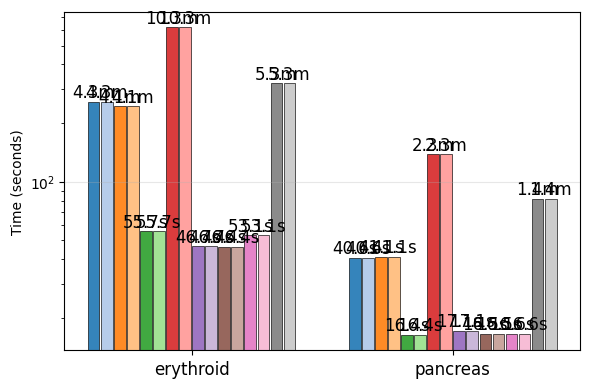

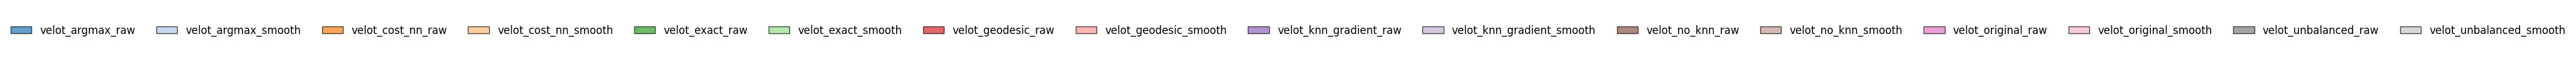

In [1]:
from velot.benchmark import benchmark_summary_table, benchmark_dotplot, benchmark_comparison_individual

benchmark_summary_table(
    "benchmark_results/real",
    detail="per_dataset",
    save_csv="benchmark_results/real/summary_per_dataset.csv",
)

benchmark_dotplot("benchmark_results/real", stat="median",
    legend=False, summary=False,
    );

benchmark_comparison_individual(
    "benchmark_results/real",
    detail="per_dataset",
    save=False, show_significance=False
);